In [ ]:
from quantum_close_neighbors.grovers.probabilistic_grovers import ProbabilisticGrovers
from quantum_close_neighbors.grovers.qiskit_grovers import (
    QiskitGroversPhaseOracle,
    QiskitGroversStaticPhaseOracle)
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Note that n_elements should be a power of 2 for Qiskit grovers and probabilistic grovers to produce the same results
# This is because the real number of elements in Qiskit simulation is always 2^q, where q is the number of qubits

n_elements = 128
n_marked_elements = 5
p_estimate_shots = 50

100%|██████████| 11/11 [08:54<00:00, 48.63s/it]


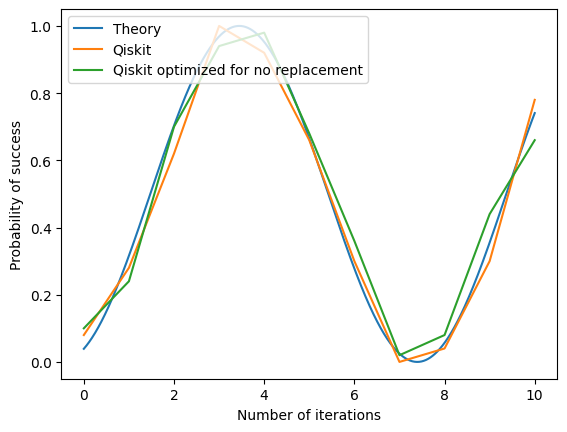

In [ ]:
num_iterations = range(0, 11)
p_successes_probabilistic = []
p_successes_qiskit = []
p_successes_qiskit_static = []


probabilistic_grovers = ProbabilisticGrovers(n_elements, n_marked_elements)
qiskit_grovers = QiskitGroversPhaseOracle.init_with_random_marked_elements(n_elements, n_marked_elements)
qiskit_grovers_static = QiskitGroversStaticPhaseOracle.init_with_random_marked_elements(n_elements, n_marked_elements)
for j in tqdm(num_iterations):

    p_success_probabilistic = probabilistic_grovers.p_success(j)
    p_successes_probabilistic.append(p_success_probabilistic)

    qiskit_p_success = qiskit_grovers.estimate_p_success(j, p_estimate_shots)
    p_successes_qiskit.append(qiskit_p_success)

    qiskit_p_success_static = qiskit_grovers_static.estimate_p_success(j, p_estimate_shots)
    p_successes_qiskit_static.append(qiskit_p_success_static)

theta = np.arcsin(np.sqrt(n_marked_elements / n_elements))
j_continuous = np.linspace(0, 10, 1000)
theoretical_prob_success = np.sin((2 * j_continuous + 1) * theta) ** 2

plt.figure()
plt.plot(j_continuous, theoretical_prob_success, label='Theory')
#plt.plot(num_iterations, p_successes_probabilistic, label='Probabilistic ')
plt.plot(num_iterations, p_successes_qiskit, label='Qiskit')
plt.plot(num_iterations, p_successes_qiskit_static, label='Qiskit optimized for no replacement')
plt.xlabel('Number of iterations')
plt.ylabel('Probability of success')
plt.legend(loc='upper left')
plt.show()